# Track 4 — Rapid Water Safety Screening
### Water Potability Classification (Classical ML)

**Kya karna hai:** Water chemistry readings se predict karna hai ke sample potable (safe) hai ya nahi.

**Dataset download karo yahan se (pehle ye zaroori hai):**
https://www.kaggle.com/datasets/adityakadiwal/water-potability

Download karke `water_potability.csv` ko isi folder me rakho jahan ye notebook hai
(Google Colab use kar rahi ho to left sidebar > Files > upload icon se upload kar do).

**Pipeline:** Data loading → EDA → Baseline → Multiple models → Best model evaluation → Error analysis

## 1. Imports
Sab libraries jo chahiye honge, ek sath import kar lo.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                              ConfusionMatrixDisplay, accuracy_score, f1_score)

sns.set_style('whitegrid')
np.random.seed(42)

## 2. Data Loading
CSV file load karo aur pehli nazar dalo.

In [5]:
df = pd.read_csv('water_potability.csv')
print("Shape:", df.shape)
df.head()

Shape: (3276, 10)


,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3276 entries, 0 to 3275
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ph               2785 non-null   float64
 1   Hardness         3276 non-null   float64
 2   Solids           3276 non-null   float64
 3   Chloramines      3276 non-null   float64
 4   Sulfate          2495 non-null   float64
 5   Conductivity     3276 non-null   float64
 6   Organic_carbon   3276 non-null   float64
 7   Trihalomethanes  3114 non-null   float64
 8   Turbidity        3276 non-null   float64
 9   Potability       3276 non-null   int64  
dtypes: float64(9), int64(1)
memory usage: 256.1 KB


In [7]:
# Missing values kitni hain, har column me
df.isnull().sum()

ph                 491
Hardness             0
Solids               0
Chloramines          0
Sulfate            781
Conductivity         0
Organic_carbon       0
Trihalomethanes    162
Turbidity            0
Potability           0
dtype: int64

## 3. EDA (Exploratory Data Analysis)
Yahan hum dekhenge: class balance, missing value pattern, feature distributions, correlations.

Potability
0    0.60989
1    0.39011
Name: proportion, dtype: float64


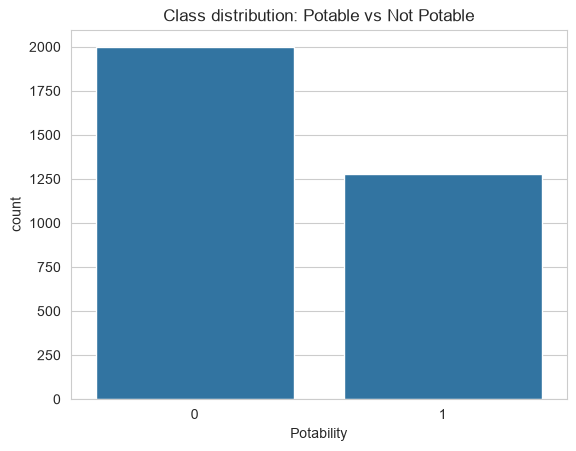

In [8]:
# Class distribution — potable(1) vs not potable(0)
print(df['Potability'].value_counts(normalize=True))

sns.countplot(x='Potability', data=df)
plt.title('Class distribution: Potable vs Not Potable')
plt.show()

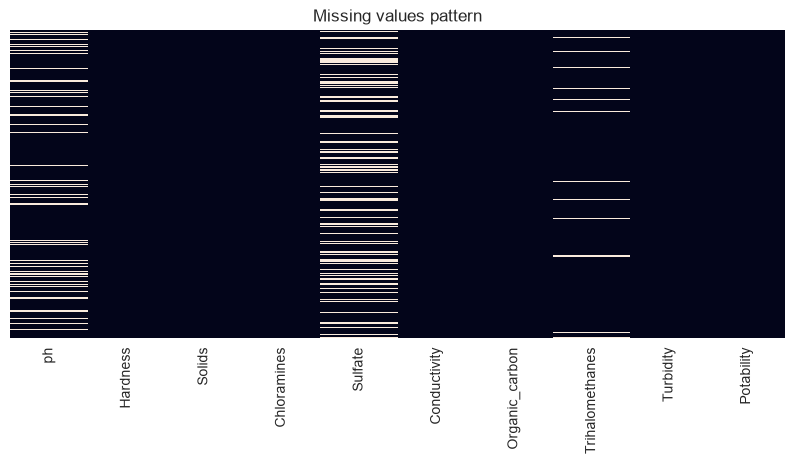

In [9]:
# Missing values visually
plt.figure(figsize=(10,4))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False)
plt.title('Missing values pattern')
plt.show()

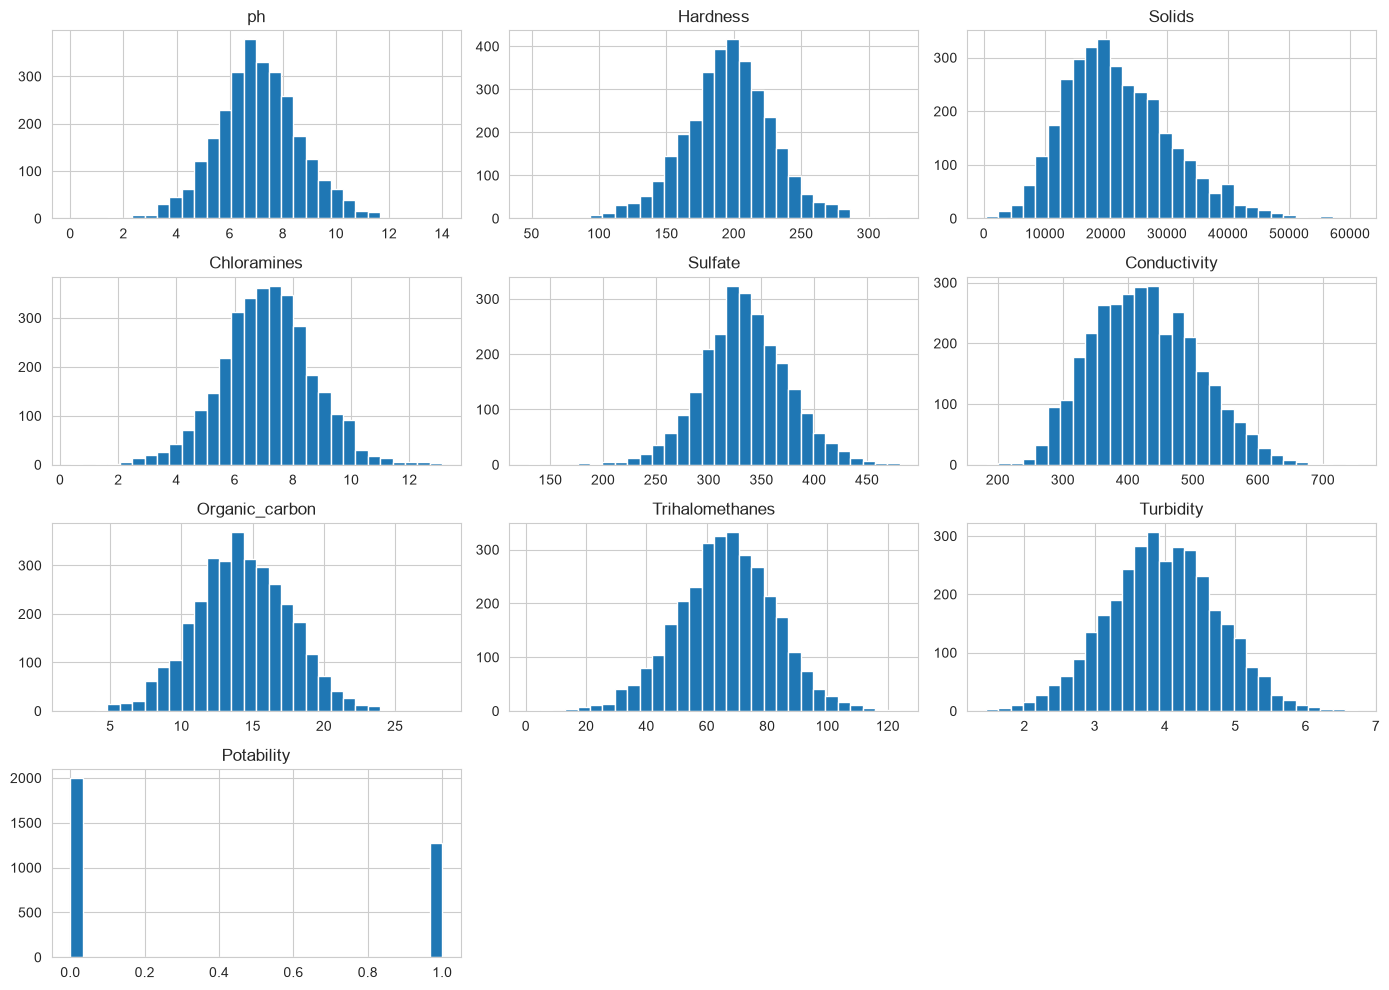

In [10]:
# Feature distributions — har numeric column ka histogram
df.hist(figsize=(14,10), bins=30)
plt.tight_layout()
plt.show()

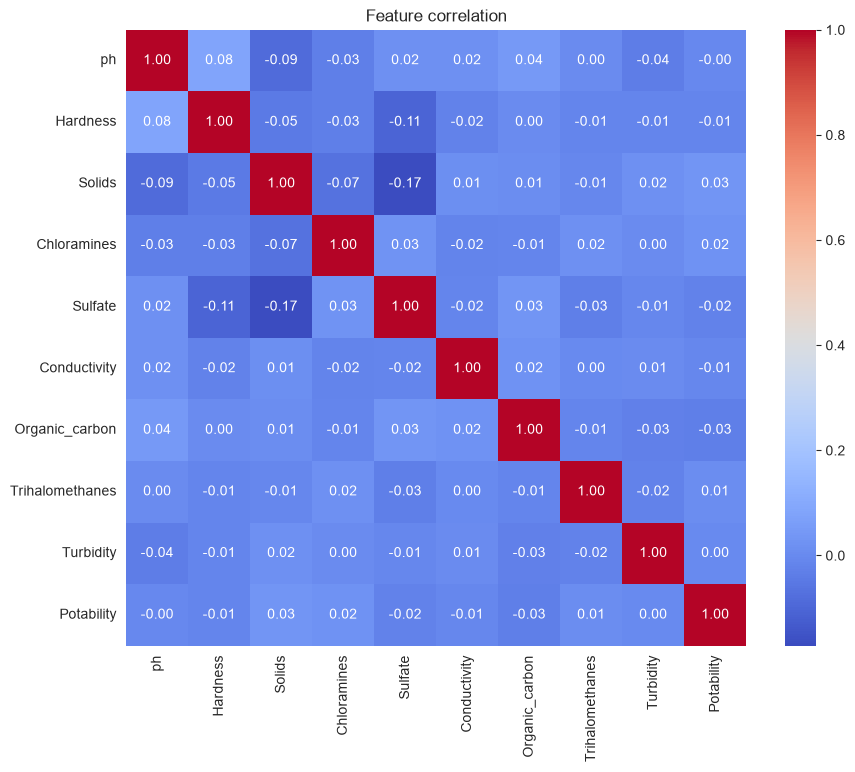

In [11]:
# Correlation heatmap
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Feature correlation')
plt.show()

**Yahan note kar lo (memo ke liye kaam aayega):**
- Kaunse columns me missing values sabse zyada hain?
- Classes balanced hain ya imbalanced?
- Koi feature strongly correlated hai potability ke sath?

## 4. Preprocessing
Missing values fill karo (median imputation), train/test split karo, aur features scale karo.

In [12]:
X = df.drop('Potability', axis=1)
y = df['Potability']

# 80/20 split — stratify=y taake dono splits me class ratio same rahe
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Missing values ko median se fill karo (train se seekho, test pe apply karo — leakage avoid karne ke liye)
imputer = SimpleImputer(strategy='median')
X_train_imp = imputer.fit_transform(X_train)
X_test_imp = imputer.transform(X_test)

# Scale karo — Logistic Regression aur SVM scale-sensitive hote hain
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imp)
X_test_scaled = scaler.transform(X_test_imp)

print("Train shape:", X_train_scaled.shape, " Test shape:", X_test_scaled.shape)

Train shape: (2620, 9)  Test shape: (656, 9)


## 5. Baseline — Majority Class Predictor
Ye hamara "baseline to beat" hai. Har model isse behtar perform karna chahiye.

In [13]:
baseline = DummyClassifier(strategy='most_frequent')
baseline.fit(X_train_scaled, y_train)
baseline_pred = baseline.predict(X_test_scaled)

baseline_acc = accuracy_score(y_test, baseline_pred)
baseline_f1 = f1_score(y_test, baseline_pred)

print(f"Baseline Accuracy: {baseline_acc:.3f}")
print(f"Baseline F1 Score: {baseline_f1:.3f}")

Baseline Accuracy: 0.610
Baseline F1 Score: 0.000


## 6. Multiple Algorithms — Train & Compare
3 classical algorithms try kar rahe hain. `class_weight='balanced'` use kiya hai
kyunki dataset thoda imbalanced hota hai.

In [14]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42),
    'SVM': SVC(class_weight='balanced', random_state=42)
}

cv_results = {}
for name, model in models.items():
    scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='f1')
    cv_results[name] = scores.mean()
    print(f"{name:20s} CV F1 = {scores.mean():.3f}  (+/- {scores.std():.3f})")

Logistic Regression  CV F1 = 0.416  (+/- 0.025)
Random Forest        CV F1 = 0.510  (+/- 0.018)
SVM                  CV F1 = 0.551  (+/- 0.036)


In [15]:
# Best model chuno (highest CV F1)
best_model_name = max(cv_results, key=cv_results.get)
print("Best model:", best_model_name)

best_model = models[best_model_name]
best_model.fit(X_train_scaled, y_train)
y_pred = best_model.predict(X_test_scaled)

Best model: SVM


**Justify karna hai (rubric ke liye zaroori hai):** kyun ye algorithm best hai —
CV scores compare karke likho, sirf ek number nahi, reasoning bhi.

## 7. Evaluation
Accuracy ke sath precision/recall/F1 bhi dekho — imbalanced data pe akela accuracy misleading hoti hai.

In [16]:
print(f"Test Accuracy: {accuracy_score(y_test, y_pred):.3f}")
print(f"Test F1 Score: {f1_score(y_test, y_pred):.3f}\n")
print(classification_report(y_test, y_pred, target_names=['Not Potable','Potable']))

Test Accuracy: 0.622
Test F1 Score: 0.512

              precision    recall  f1-score   support

 Not Potable       0.69      0.69      0.69       400
     Potable       0.52      0.51      0.51       256

    accuracy                           0.62       656
   macro avg       0.60      0.60      0.60       656
weighted avg       0.62      0.62      0.62       656



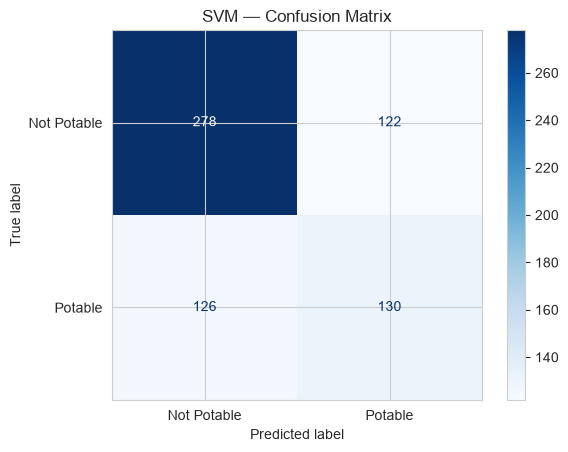

In [17]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Potable','Potable'])
disp.plot(cmap='Blues')
plt.title(f'{best_model_name} — Confusion Matrix')
plt.show()

## 8. Error Analysis
Kam se kam 3 misclassified samples inspect karo — rubric requirement hai.

In [18]:
X_test_reset = X_test.reset_index(drop=True)
y_test_reset = y_test.reset_index(drop=True)
y_pred_series = pd.Series(y_pred)

misclassified_idx = np.where(y_pred_series != y_test_reset)[0]
print(f"Total misclassified: {len(misclassified_idx)} out of {len(y_test_reset)}")

# 3 misclassified samples dekho
error_examples = X_test_reset.iloc[misclassified_idx[:3]].copy()
error_examples['Actual'] = y_test_reset.iloc[misclassified_idx[:3]].values
error_examples['Predicted'] = y_pred_series.iloc[misclassified_idx[:3]].values
error_examples

Total misclassified: 248 out of 656


,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Actual,Predicted
0,NaN,188.743562,19037.462638,6.034236,NaN,388.065857,15.149068,78.499418,2.723651,1,0
8,8.128270,231.167537,19954.575554,5.138838,349.067363,386.071149,15.018085,63.340968,4.678742,1,0
9,8.473249,129.240081,20465.588609,7.212917,NaN,590.906574,15.292706,63.939821,4.810185,1,0


**Dekho aur likho:** in 3 examples me kya common hai? Missing values thay? Borderline chemistry values thay?
Ye observation deployment memo me "what happens when it's wrong" section me use hogi.

## 9. Baseline vs Best Model — Comparison Table

In [19]:
comparison = pd.DataFrame({
    'Model': ['Baseline (majority class)', best_model_name],
    'Accuracy': [baseline_acc, accuracy_score(y_test, y_pred)],
    'F1 Score': [baseline_f1, f1_score(y_test, y_pred)]
})
comparison

,Model,Accuracy,F1 Score
0,Baseline (majority class),0.609756,0.000000
1,SVM,0.621951,0.511811
